## 1. Make a binary classification dataset with Scikit-Learn's make_moons() function.

- For consistency, the dataset should have 1000 samples and a random_state=42.
- Turn the data into PyTorch tensors. Split the data into training and test sets using train_test_split with 80% training and 20% testing.

In [1]:
# import the libraries
import torch
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split

In [4]:
# create the dataset
X, y = make_moons(
    n_samples=1000,
    noise = 0.1,
    random_state = 42
)
print(X.shape) # each sample has 2 features
print(y.shape) # contains one label for each sample

(1000, 2)
(1000,)


In [6]:
# convert to pytorch tensors
X = torch.from_numpy(X).type(torch.float)
y = torch.from_numpy(y).type(torch.float)

In [7]:
type(X)

torch.Tensor

In [9]:
# train test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print(X_train.shape)
print(X_test.shape)

print(y_train.shape)
print(y_test.shape)

torch.Size([800, 2])
torch.Size([200, 2])
torch.Size([800])
torch.Size([200])


## 2. Build a model by subclassing nn.Module that incorporates non-linear activation functions and is capable of fitting the data you created in 1.

- Feel free to use any combination of PyTorch layers (linear and non-linear) you want.

In [10]:
from torch import nn

In [22]:
# build the model
class MoonModel(nn.Module):
    def __init__(self):
        super().__init__() # initializes the parent nn module

        self.layer1 = nn.Linear(in_features=2, out_features=10)

        self.layer2 = nn.Linear(in_features=10, out_features=10)

        self.layer3 = nn.Linear(in_features=10, out_features=1)

        self.relu = nn.ReLU()
    def forward(self,x):
        x = self.layer1(x)
        x = self.relu(x)

        x = self.layer2(x)
        x = self.relu(x)

        x = self.layer3(x)

        return x


## 3. Setup a binary classification compatible loss function and optimizer to use when training the model.

In [23]:
model = MoonModel()

In [24]:
loss_fn = nn.BCEWithLogitsLoss()

In [25]:
optimizer = torch.optim.SGD(params=model.parameters(), lr=0.1)

## 4. Create a training and testing loop to fit the model you created in 2 to the data you created in 1.

- To measure model accuracy, you can create your own accuracy function or use the accuracy function in TorchMetrics.
- Train the model for long enough for it to reach over 96% accuracy.
- The training loop should output progress every 10 epochs of the model's training and test set loss and accuracy.

In [26]:
def accuracy_fn(y_true, y_pred):
    correct = torch.eq(y_true, y_pred).sum().item()
    acc = (correct / len(y_pred)) * 100
    return acc

In [27]:
for epoch in range(epochs):

    # --------------------
    # Training
    # --------------------
    model.train()

    # Forward pass
    y_logits = model(X_train).squeeze()

    # Convert logits to predictions (0 or 1)
    y_pred = torch.round(torch.sigmoid(y_logits))

    # Calculate loss
    loss = loss_fn(y_logits, y_train)

    # Calculate accuracy
    acc = accuracy_fn(y_train, y_pred)

    # Zero gradients
    optimizer.zero_grad()

    # Backpropagation
    loss.backward()

    # Update weights
    optimizer.step()

    # --------------------
    # Testing
    # --------------------
    model.eval()

    with torch.inference_mode():

        test_logits = model(X_test).squeeze()

        test_pred = torch.round(torch.sigmoid(test_logits))

        test_loss = loss_fn(test_logits, y_test)

        test_acc = accuracy_fn(y_test, test_pred)

    # Print progress every 10 epochs
    if epoch % 10 == 0:
        print(
            f"Epoch: {epoch:4d} | "
            f"Train Loss: {loss:.5f} | "
            f"Train Acc: {acc:.2f}% | "
            f"Test Loss: {test_loss:.5f} | "
            f"Test Acc: {test_acc:.2f}%"
        )

Epoch:    0 | Train Loss: 0.67359 | Train Acc: 80.62% | Test Loss: 0.67254 | Test Acc: 81.00%
Epoch:   10 | Train Loss: 0.64777 | Train Acc: 80.88% | Test Loss: 0.64875 | Test Acc: 76.50%
Epoch:   20 | Train Loss: 0.61870 | Train Acc: 79.75% | Test Loss: 0.62162 | Test Acc: 76.00%
Epoch:   30 | Train Loss: 0.58358 | Train Acc: 79.75% | Test Loss: 0.58918 | Test Acc: 77.00%
Epoch:   40 | Train Loss: 0.54404 | Train Acc: 80.25% | Test Loss: 0.55306 | Test Acc: 76.50%
Epoch:   50 | Train Loss: 0.50396 | Train Acc: 80.75% | Test Loss: 0.51655 | Test Acc: 78.00%
Epoch:   60 | Train Loss: 0.46668 | Train Acc: 81.50% | Test Loss: 0.48214 | Test Acc: 78.50%
Epoch:   70 | Train Loss: 0.43449 | Train Acc: 82.00% | Test Loss: 0.45181 | Test Acc: 79.50%
Epoch:   80 | Train Loss: 0.40773 | Train Acc: 82.12% | Test Loss: 0.42598 | Test Acc: 81.00%
Epoch:   90 | Train Loss: 0.38542 | Train Acc: 82.75% | Test Loss: 0.40372 | Test Acc: 80.00%
Epoch:  100 | Train Loss: 0.36673 | Train Acc: 83.12% | Test

## 5. Make predictions with your trained model and plot them using the plot_decision_boundary() function created in this notebook.

In [28]:
model.eval()

with torch.inference_mode():
    test_logits = model(X_test).squeeze()
    test_preds = torch.round(torch.sigmoid(test_logits))

In [32]:
import matplotlib.pyplot as plt
from helper_functions import plot_decision_boundary

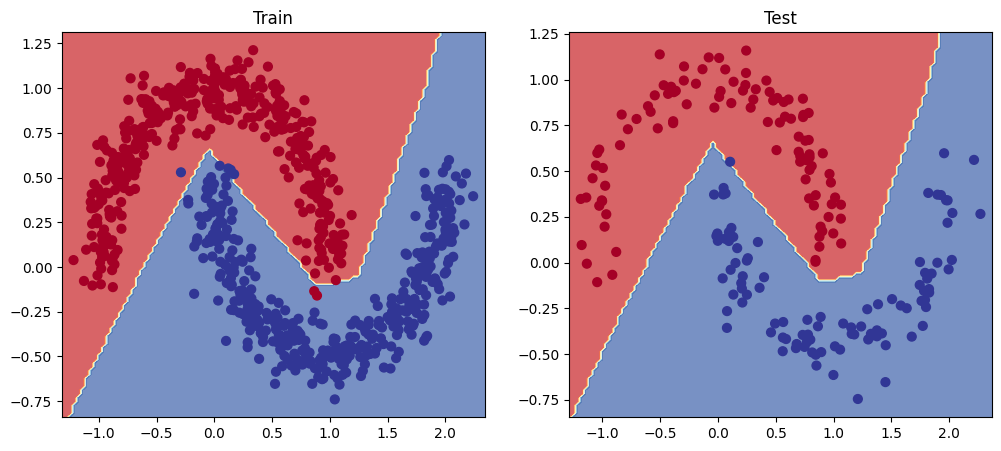

In [33]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.title("Train")
plot_decision_boundary(model, X_train, y_train)

plt.subplot(1, 2, 2)
plt.title("Test")
plot_decision_boundary(model, X_test, y_test)

plt.show()

## 6. Replicate the Tanh (hyperbolic tangent) activation function in pure PyTorch.

- Feel free to reference the ML cheatsheet website for the formula.

In [34]:
def tanh(x):
    return (torch.exp(x) - torch.exp(-x)) / (torch.exp(x) + torch.exp(-x))

In [35]:
x = torch.linspace(-5, 5, steps=11)

print("Our Tanh:")
print(tanh(x))

print("\nPyTorch Tanh:")
print(torch.tanh(x))

Our Tanh:
tensor([-0.9999, -0.9993, -0.9951, -0.9640, -0.7616,  0.0000,  0.7616,  0.9640,
         0.9951,  0.9993,  0.9999])

PyTorch Tanh:
tensor([-0.9999, -0.9993, -0.9951, -0.9640, -0.7616,  0.0000,  0.7616,  0.9640,
         0.9951,  0.9993,  0.9999])
